# Avvio rapido sull'architettura di routing sinaptico (SRA).

Questo notebook è una demo per sperimentare facilmente il meccanismo di base di SRA e la sua caratteristica principale, il comportamento di "routing".
Puoi osservare il comportamento di SRA semplicemente eseguendo le celle in ordine dall'alto in un ambiente come Google Colab.

## 1. Configurazione dell'ambiente
Se lo stai eseguendo su Google Colab, esegui la cella seguente per clonare il repository e installare le librerie richieste.

In [1]:
# Run only in Colab environment (skip if local)
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter
    !pip install torch matplotlib seaborn

# Add path
sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')


## 2. Importa librerie e prepara modello
Inizializzare il modello SRA MoE (Mixture of Experts).

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from src.sra_gpu_models import MoESRAModel
class MoESRAConfig:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model with a small configuration
config = MoESRAConfig(
    vocab_size=100,
    d_model=64,
    n_layers=2,
    n_heads=4,
    num_synapses=4,  # 4 experts (synapses)
    k=2,       # Select 2 synapses per token
    max_seq_len=64
)
model = MoESRAModel(config.vocab_size, config.d_model, config.n_layers, config.num_synapses, config.k, syn_hidden=128).to(device)
print("Model initialized!")

Using device: cpu
Model initialized!


## 3. Passaggio in avanti e controllo del percorso con dati fittizi
Inserisci dati arbitrari e controlla come il modello si instrada verso ciascuna sinapsi (esperto).

In [3]:
# Dummy data with batch size 2 and sequence length 10
x = torch.randint(0, config.vocab_size, (2, 10)).to(device)

model.eval()
with torch.no_grad():
    y_in = torch.cat([torch.full((x.size(0), 1), 1, dtype=torch.long, device=device), x[:, :-1]], dim=1)
    outputs, routing_weights, _ = model(x, y_in)
    
print("Output shape:", outputs.shape)
print("Number of layers with routing info:", len(routing_weights))

Output shape: torch.Size([2, 10, 100])
Number of layers with routing info: 2


## 4. Visualizzazione del percorso
Visualizza con una mappa termica a quale sinapsi (esperto) è stato instradato ciascun token di input in un livello specifico.
* Qui mostriamo il routing in uno stato casuale prima dell'addestramento.Man mano che la formazione progredisce e si specializza in un compito, questo percorso mostrerà un pregiudizio (specializzazione).

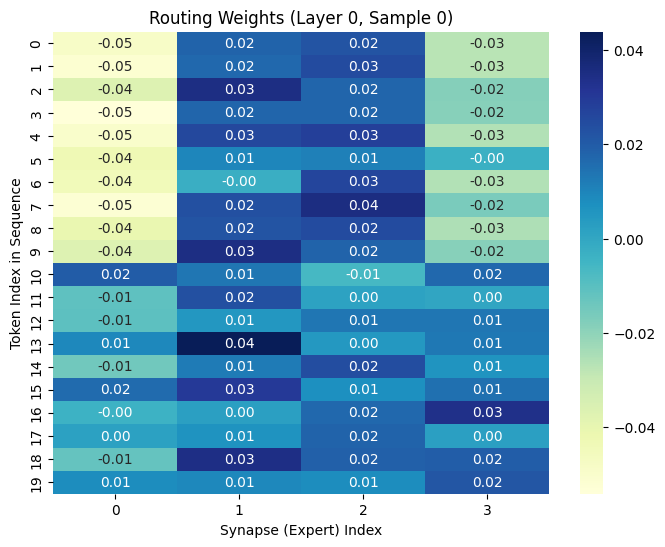

In [4]:
# Get routing weights of the first layer of the first sample
layer_idx = 0
sample_idx = 0
weights = routing_weights[layer_idx][sample_idx].cpu().numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(weights, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title(f"Routing Weights (Layer {layer_idx}, Sample {sample_idx})")
plt.xlabel("Synapse (Expert) Index")
plt.ylabel("Token Index in Sequence")
plt.show()